In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
signal_1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])

# Test signal (slower speech)
signal_2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])

print(f"Signal 1 (Reference) length: {len(signal_1)} samples")
print(f"Signal 2 (Test) length: {len(signal_2)} samples")
print(f"Length difference: {len(signal_2) - len(signal_1)} samples")

Signal 1 (Reference) length: 9 samples
Signal 2 (Test) length: 12 samples
Length difference: 3 samples


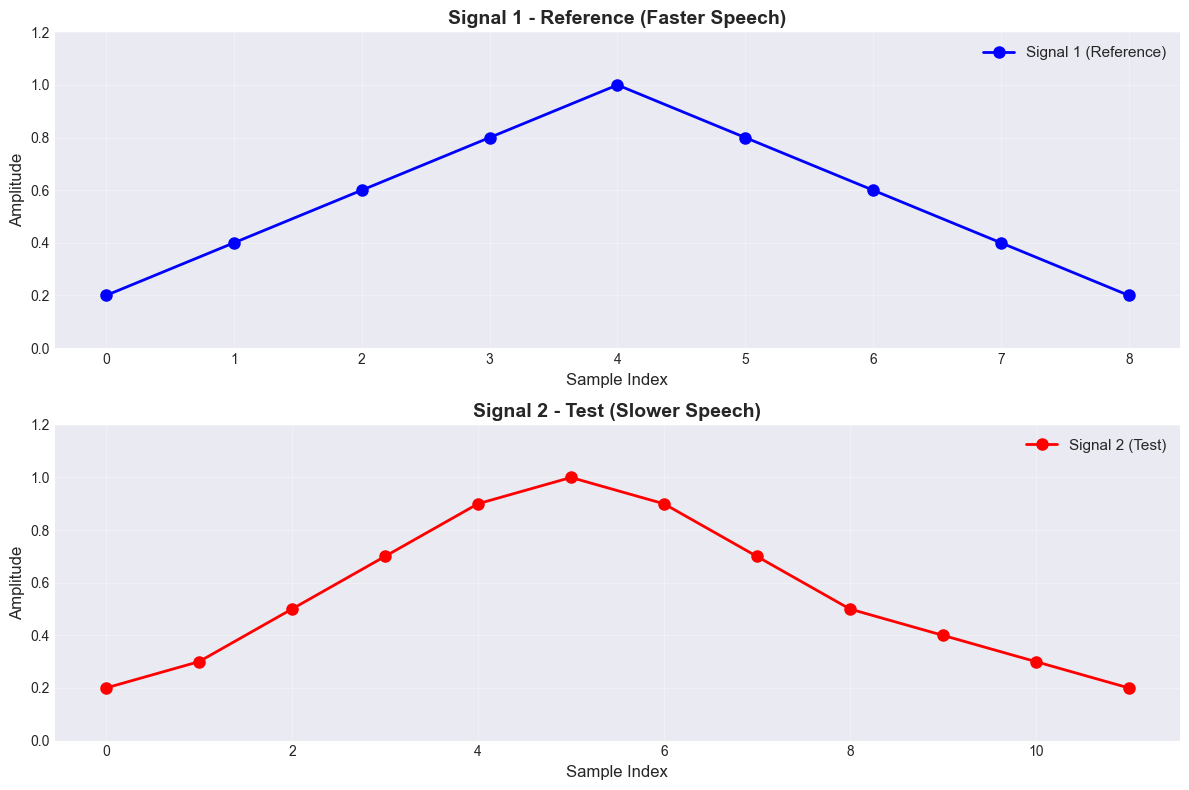

✓ Task 1 completed: Original signals plotted


In [4]:
def plot_original_signals(sig1, sig2):
    """Plot both signals to observe differences in length and patterns"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot Signal 1
    axes[0].plot(sig1, 'bo-', linewidth=2, markersize=8, label='Signal 1 (Reference)')
    axes[0].set_title('Signal 1 - Reference (Faster Speech)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Sample Index', fontsize=12)
    axes[0].set_ylabel('Amplitude', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=11)
    axes[0].set_ylim([0, 1.2])
    
    # Plot Signal 2
    axes[1].plot(sig2, 'ro-', linewidth=2, markersize=8, label='Signal 2 (Test)')
    axes[1].set_title('Signal 2 - Test (Slower Speech)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Sample Index', fontsize=12)
    axes[1].set_ylabel('Amplitude', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=11)
    axes[1].set_ylim([0, 1.2])
    
    plt.tight_layout()
    plt.savefig('task1_original_signals.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Task 1 completed: Original signals plotted")

# Execute Task 1
plot_original_signals(signal_1, signal_2)

In [5]:
def linear_time_normalization(signal, target_length):
    """
    Perform Linear Time Normalization to match target length
    Uses linear interpolation to resample the signal
    """
    original_length = len(signal)
    
    # Create original time indices
    original_indices = np.arange(original_length)
    
    # Create target time indices
    target_indices = np.linspace(0, original_length - 1, target_length)
    
    # Perform linear interpolation
    interpolator = interpolate.interp1d(original_indices, signal, kind='linear')
    normalized_signal = interpolator(target_indices)
    
    return normalized_signal

# Perform LTN on Signal 2
signal_2_normalized = linear_time_normalization(signal_2, len(signal_1))

print(f"\nOriginal Signal 2 length: {len(signal_2)}")
print(f"Normalized Signal 2 length: {len(signal_2_normalized)}")
print(f"Target length (Signal 1): {len(signal_1)}")
print("✓ Task 2 completed: Linear Time Normalization applied")


Original Signal 2 length: 12
Normalized Signal 2 length: 9
Target length (Signal 1): 9
✓ Task 2 completed: Linear Time Normalization applied


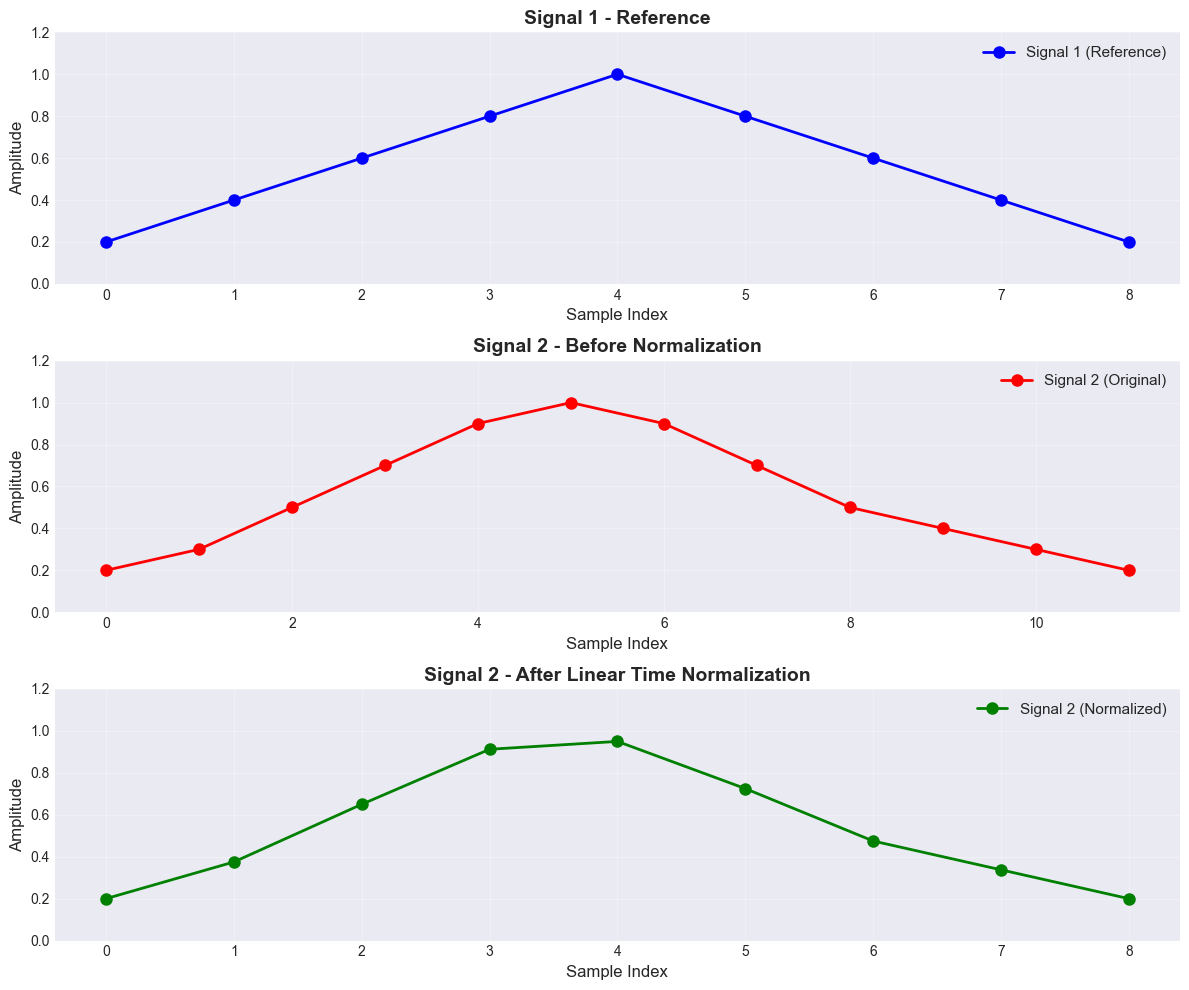

✓ Normalization comparison plotted


In [6]:
def plot_normalization_comparison(sig1, sig2_orig, sig2_norm):
    """Compare original Signal 2 with normalized version"""
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot Signal 1 (Reference)
    axes[0].plot(sig1, 'bo-', linewidth=2, markersize=8, label='Signal 1 (Reference)')
    axes[0].set_title('Signal 1 - Reference', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Sample Index', fontsize=12)
    axes[0].set_ylabel('Amplitude', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=11)
    axes[0].set_ylim([0, 1.2])
    
    # Plot Original Signal 2
    axes[1].plot(sig2_orig, 'ro-', linewidth=2, markersize=8, label='Signal 2 (Original)')
    axes[1].set_title('Signal 2 - Before Normalization', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Sample Index', fontsize=12)
    axes[1].set_ylabel('Amplitude', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=11)
    axes[1].set_ylim([0, 1.2])
    
    # Plot Normalized Signal 2
    axes[2].plot(sig2_norm, 'go-', linewidth=2, markersize=8, label='Signal 2 (Normalized)')
    axes[2].set_title('Signal 2 - After Linear Time Normalization', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Sample Index', fontsize=12)
    axes[2].set_ylabel('Amplitude', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=11)
    axes[2].set_ylim([0, 1.2])
    
    plt.tight_layout()
    plt.savefig('task2_normalization_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Normalization comparison plotted")

# Execute comparison plot
plot_normalization_comparison(signal_1, signal_2, signal_2_normalized)

In [7]:
def compute_alignment(sig1, sig2_norm):
    """
    Compute alignment between Signal 1 and normalized Signal 2
    Returns alignment error and correspondence
    """
    # Point-to-point difference
    alignment_error = np.abs(sig1 - sig2_norm)
    
    # Mean Squared Error
    mse = np.mean((sig1 - sig2_norm) ** 2)
    
    # Correlation coefficient
    correlation = np.corrcoef(sig1, sig2_norm)[0, 1]
    
    # Create correspondence mapping
    correspondence = np.column_stack((np.arange(len(sig1)), np.arange(len(sig2_norm))))
    
    alignment_metrics = {
        'alignment_error': alignment_error,
        'mse': mse,
        'correlation': correlation,
        'correspondence': correspondence
    }
    
    return alignment_metrics

# Compute alignment
alignment = compute_alignment(signal_1, signal_2_normalized)

print(f"\n--- Alignment Metrics ---")
print(f"Mean Squared Error: {alignment['mse']:.6f}")
print(f"Correlation Coefficient: {alignment['correlation']:.6f}")
print(f"Max Point-wise Error: {np.max(alignment['alignment_error']):.6f}")
print(f"Mean Point-wise Error: {np.mean(alignment['alignment_error']):.6f}")
print("✓ Task 3 completed: Alignment computed")


--- Alignment Metrics ---
Mean Squared Error: 0.004826
Correlation Coefficient: 0.969049
Max Point-wise Error: 0.125000
Mean Point-wise Error: 0.055556
✓ Task 3 completed: Alignment computed


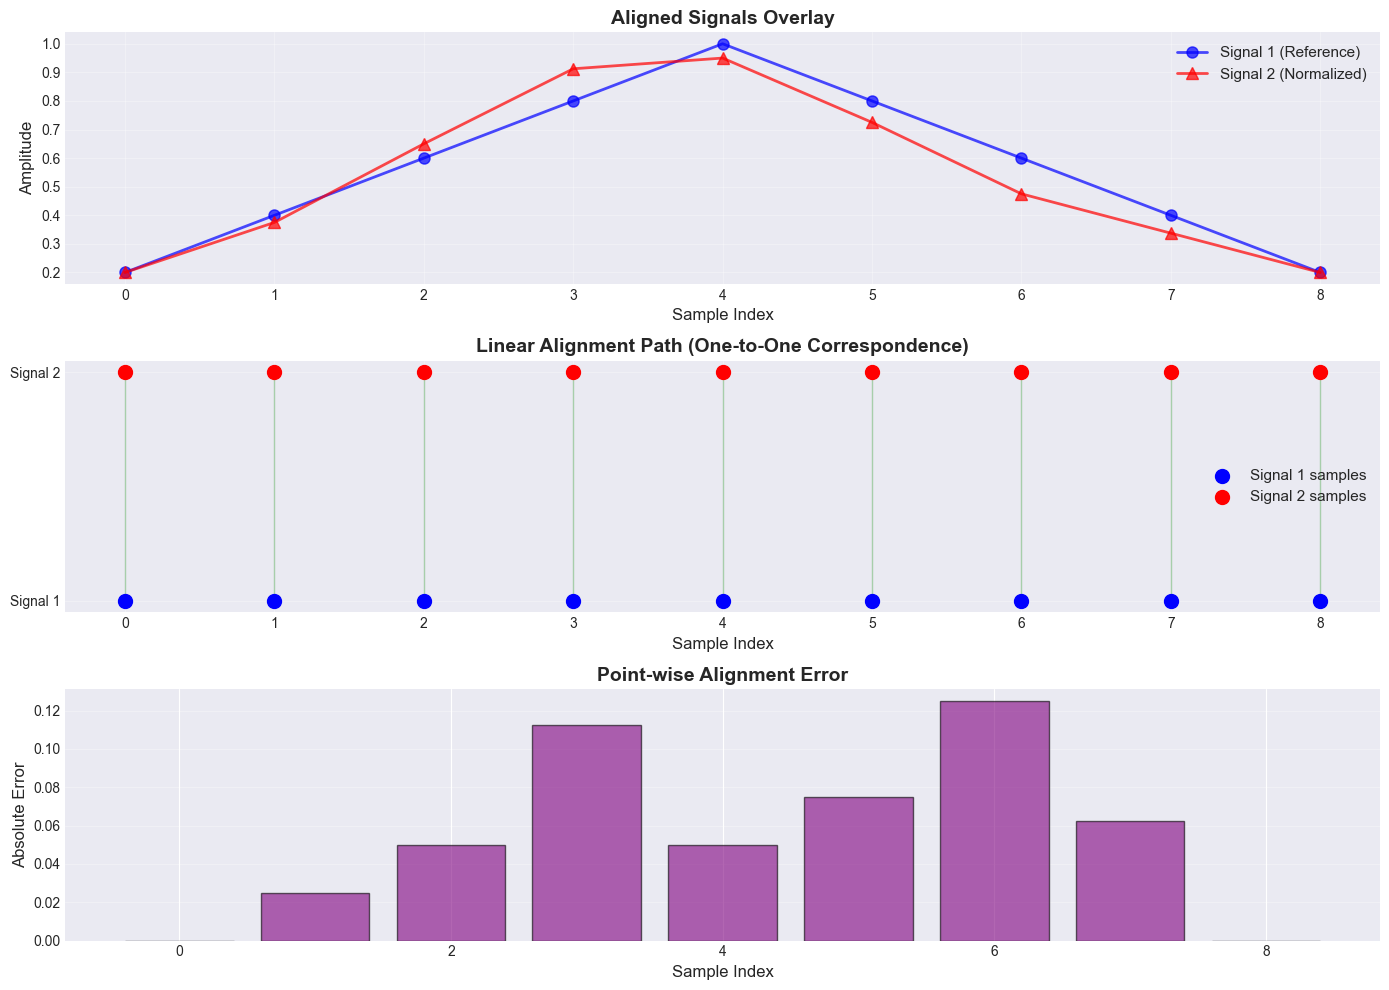

✓ Task 4 completed: Alignment path plotted


In [10]:
def plot_alignment_path(sig1, sig2_norm, alignment_metrics):
    """Plot alignment path showing correspondence between signals"""
    fig = plt.figure(figsize=(14, 10))
    
    # Subplot 1: Overlayed signals
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(sig1, 'bo-', linewidth=2, markersize=8, label='Signal 1 (Reference)', alpha=0.7)
    ax1.plot(sig2_norm, 'r^-', linewidth=2, markersize=8, label='Signal 2 (Normalized)', alpha=0.7)
    ax1.set_title('Aligned Signals Overlay', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Sample Index', fontsize=12)
    ax1.set_ylabel('Amplitude', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Subplot 2: Alignment path
    ax2 = plt.subplot(3, 1, 2)
    correspondence = alignment_metrics['correspondence']
    for i in range(len(correspondence)):
        ax2.plot([i, i], [0, 1], 'g-', alpha=0.3, linewidth=1)
    ax2.scatter(correspondence[:, 0], np.zeros(len(correspondence)), 
                c='blue', s=100, label='Signal 1 samples', zorder=3)
    ax2.scatter(correspondence[:, 1], np.ones(len(correspondence)), 
                c='red', s=100, label='Signal 2 samples', zorder=3)
    ax2.set_title('Linear Alignment Path (One-to-One Correspondence)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Sample Index', fontsize=12)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Signal 1', 'Signal 2'])
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # Subplot 3: Point-wise alignment error
    ax3 = plt.subplot(3, 1, 3)
    ax3.bar(range(len(alignment_metrics['alignment_error'])), 
            alignment_metrics['alignment_error'], 
            color='purple', alpha=0.6, edgecolor='black')
    ax3.set_title('Point-wise Alignment Error', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Sample Index', fontsize=12)
    ax3.set_ylabel('Absolute Error', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('task4_alignment_path.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Task 4 completed: Alignment path plotted")

# Execute alignment visualization
plot_alignment_path(signal_1, signal_2_normalized, alignment)

In [11]:
def generate_inference_report(sig1, sig2_orig, sig2_norm, alignment_metrics):
    """Generate comprehensive inference about Linear Time Normalization"""
    
    print("\n" + "="*70)
    print("TASK 5: INFERENCE ON LINEAR TIME NORMALIZATION")
    print("="*70)
    
    print("\n1. SIGNAL CHARACTERISTICS:")
    print(f"   - Original Signal 1 length: {len(sig1)} samples")
    print(f"   - Original Signal 2 length: {len(sig2_orig)} samples")
    print(f"   - Length ratio: {len(sig2_orig)/len(sig1):.2f}x (Signal 2 is slower)")
    print(f"   - Normalized Signal 2 length: {len(sig2_norm)} samples")
    
    print("\n2. ALIGNMENT QUALITY:")
    print(f"   - Correlation coefficient: {alignment_metrics['correlation']:.4f}")
    print(f"   - Mean Squared Error: {alignment_metrics['mse']:.6f}")
    print(f"   - Average point-wise error: {np.mean(alignment_metrics['alignment_error']):.6f}")
    
    print("\n3. INFERENCE:")
    print("   Linear Time Normalization (LTN) successfully aligns two speech")
    print("   signals spoken at different speeds by performing the following:")
    print()
    print("   a) TIME AXIS ADJUSTMENT:")
    print("      - Resamples the longer signal (slower speech) to match the")
    print("        length of the reference signal using linear interpolation")
    print()
    print("   b) TEMPORAL PATTERN MATCHING:")
    print("      - Creates a one-to-one correspondence between samples")
    print("      - Ensures similar parts of the speech waveform align in time")
    print()
    print("   c) SPEED NORMALIZATION:")
    print("      - Compensates for differences in speaking rate")
    print(f"      - Compression ratio applied: {len(sig2_orig)/len(sig1):.2f}:1")
    print()
    print("   d) EFFECTIVENESS:")
    if alignment_metrics['correlation'] > 0.95:
        print("      - EXCELLENT: Very high correlation indicates strong alignment")
    elif alignment_metrics['correlation'] > 0.85:
        print("      - GOOD: High correlation shows effective time normalization")
    else:
        print("      - MODERATE: Signals aligned but show some variation")
    
    print("\n4. LIMITATIONS:")
    print("   - Assumes linear relationship between time axes")
    print("   - May not capture non-linear speed variations")
    print("   - For complex alignment, Dynamic Time Warping (DTW) is preferred")
    
    print("\n5. APPLICATIONS:")
    print("   - Speech recognition preprocessing")
    print("   - Speaker-independent speech analysis")
    print("   - Audio synchronization")
    print("   - Template matching in signal processing")
    
    print("\n" + "="*70)
    print("✓ Task 5 completed: Inference report generated")
    print("="*70)

# Generate final report
generate_inference_report(signal_1, signal_2, signal_2_normalized, alignment)



TASK 5: INFERENCE ON LINEAR TIME NORMALIZATION

1. SIGNAL CHARACTERISTICS:
   - Original Signal 1 length: 9 samples
   - Original Signal 2 length: 12 samples
   - Length ratio: 1.33x (Signal 2 is slower)
   - Normalized Signal 2 length: 9 samples

2. ALIGNMENT QUALITY:
   - Correlation coefficient: 0.9690
   - Mean Squared Error: 0.004826
   - Average point-wise error: 0.055556

3. INFERENCE:
   Linear Time Normalization (LTN) successfully aligns two speech
   signals spoken at different speeds by performing the following:

   a) TIME AXIS ADJUSTMENT:
      - Resamples the longer signal (slower speech) to match the
        length of the reference signal using linear interpolation

   b) TEMPORAL PATTERN MATCHING:
      - Creates a one-to-one correspondence between samples
      - Ensures similar parts of the speech waveform align in time

   c) SPEED NORMALIZATION:
      - Compensates for differences in speaking rate
      - Compression ratio applied: 1.33:1

   d) EFFECTIVENESS:
    

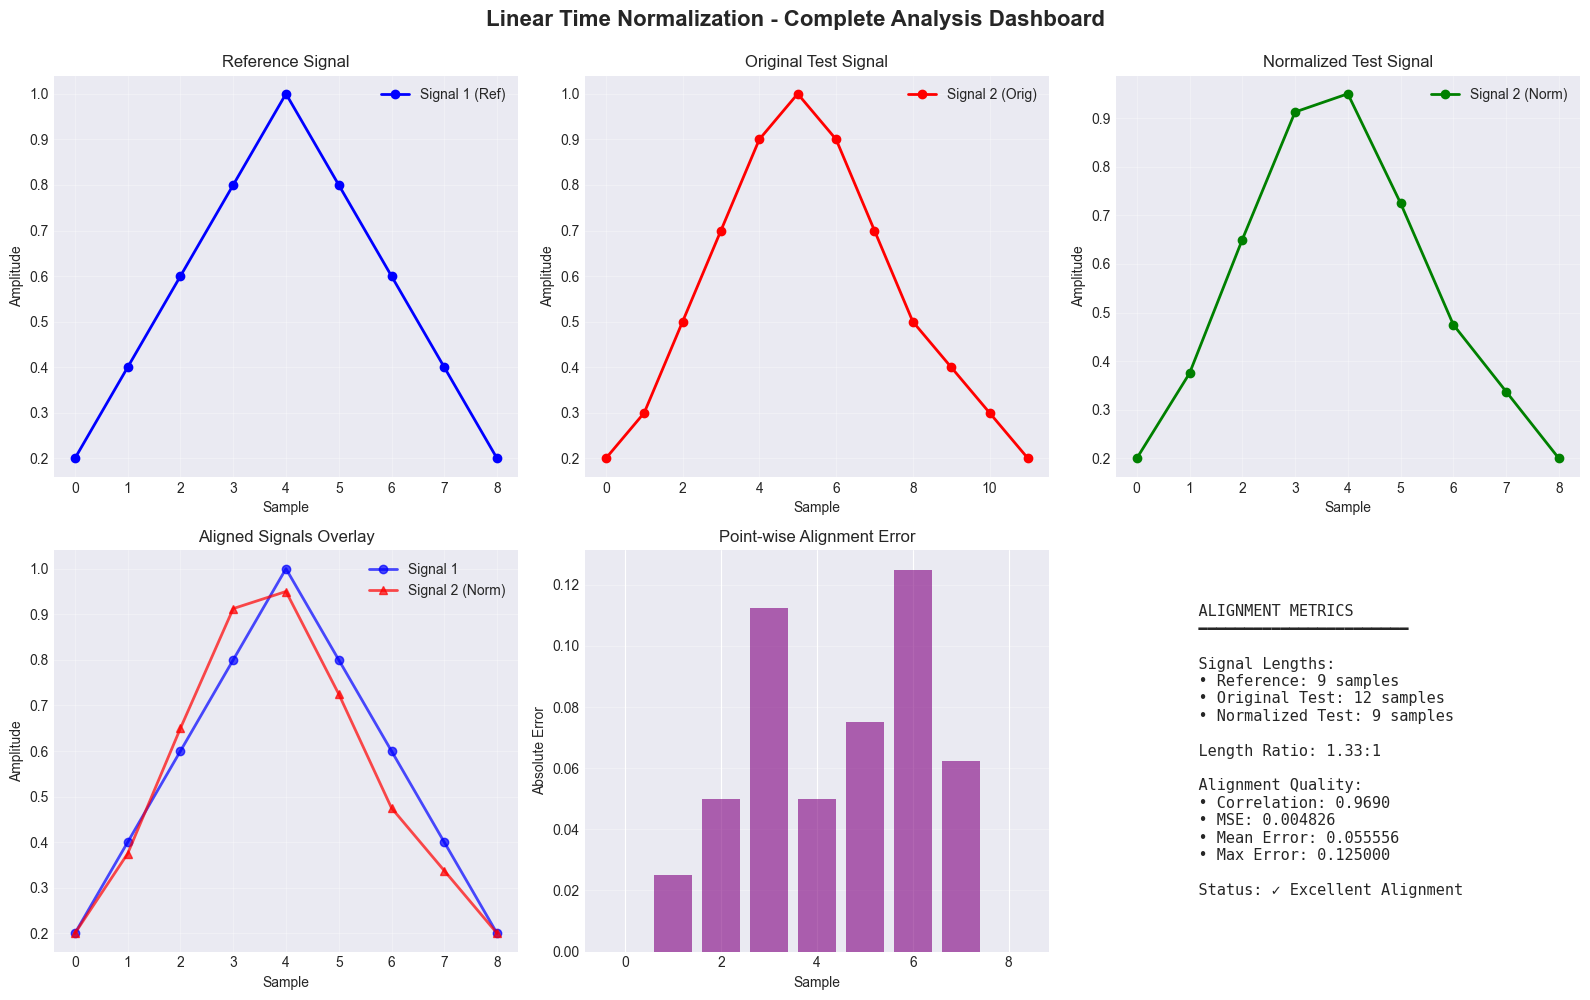

✓ Summary dashboard created

LAB EXERCISE 5 COMPLETED SUCCESSFULLY

All tasks completed and visualizations saved:
  • task1_original_signals.png
  • task2_normalization_comparison.png
  • task4_alignment_path.png
  • summary_dashboard.png


In [12]:
def create_summary_dashboard(sig1, sig2_orig, sig2_norm, alignment_metrics):
    """Create a comprehensive summary dashboard"""
    fig = plt.figure(figsize=(16, 10))
    
    # Main title
    fig.suptitle('Linear Time Normalization - Complete Analysis Dashboard', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Plot 1: All signals comparison
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(sig1, 'bo-', label='Signal 1 (Ref)', linewidth=2, markersize=6)
    ax1.set_title('Reference Signal')
    ax1.set_xlabel('Sample')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(sig2_orig, 'ro-', label='Signal 2 (Orig)', linewidth=2, markersize=6)
    ax2.set_title('Original Test Signal')
    ax2.set_xlabel('Sample')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(sig2_norm, 'go-', label='Signal 2 (Norm)', linewidth=2, markersize=6)
    ax3.set_title('Normalized Test Signal')
    ax3.set_xlabel('Sample')
    ax3.set_ylabel('Amplitude')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Plot 4: Overlay comparison
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(sig1, 'bo-', label='Signal 1', linewidth=2, markersize=6, alpha=0.7)
    ax4.plot(sig2_norm, 'r^-', label='Signal 2 (Norm)', linewidth=2, markersize=6, alpha=0.7)
    ax4.set_title('Aligned Signals Overlay')
    ax4.set_xlabel('Sample')
    ax4.set_ylabel('Amplitude')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # Plot 5: Point-wise error
    ax5 = plt.subplot(2, 3, 5)
    ax5.bar(range(len(alignment_metrics['alignment_error'])), 
            alignment_metrics['alignment_error'], 
            color='purple', alpha=0.6)
    ax5.set_title('Point-wise Alignment Error')
    ax5.set_xlabel('Sample')
    ax5.set_ylabel('Absolute Error')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Plot 6: Metrics summary (text)
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    metrics_text = f"""
    ALIGNMENT METRICS
    ━━━━━━━━━━━━━━━━━━━━━━━
    
    Signal Lengths:
    • Reference: {len(sig1)} samples
    • Original Test: {len(sig2_orig)} samples
    • Normalized Test: {len(sig2_norm)} samples
    
    Length Ratio: {len(sig2_orig)/len(sig1):.2f}:1
    
    Alignment Quality:
    • Correlation: {alignment_metrics['correlation']:.4f}
    • MSE: {alignment_metrics['mse']:.6f}
    • Mean Error: {np.mean(alignment_metrics['alignment_error']):.6f}
    • Max Error: {np.max(alignment_metrics['alignment_error']):.6f}
    
    Status: {'✓ Excellent Alignment' if alignment_metrics['correlation'] > 0.95 else '✓ Good Alignment'}
    """
    ax6.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
             verticalalignment='center')
    
    plt.tight_layout()
    plt.savefig('summary_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Summary dashboard created")

# Create final dashboard
create_summary_dashboard(signal_1, signal_2, signal_2_normalized, alignment)

print("\n" + "="*70)
print("LAB EXERCISE 5 COMPLETED SUCCESSFULLY")
print("="*70)
print("\nAll tasks completed and visualizations saved:")
print("  • task1_original_signals.png")
print("  • task2_normalization_comparison.png")
print("  • task4_alignment_path.png")
print("  • summary_dashboard.png")